# 08. Профили экономических кластеров

Здесь переводим технические cluster labels в интерпретируемые профили. Нас интересует структура пяти экономических долей.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Загрузка данных

Объединяем исходные признаки и динамические назначения кластеров.

In [2]:
features = pd.read_parquet(
    "../data/processed/features_basic.parquet"
)

clusters = pd.read_parquet(
    "../data/processed/clusters_all_months.parquet"
)

features["date"] = pd.to_datetime(features["date"])
clusters["date"] = pd.to_datetime(clusters["date"])

model_features = [
    "food_share",
    "health_share",
    "marketplaces_share",
    "catering_share",
    "transport_share"
]

## 2. Формирование профилей кластеров

Рассчитываем средние экономические доли для каждого месячного кластера.

In [3]:
cluster_data = clusters.merge(
    features[
        ["territory_id", "date"] + model_features
    ],
    on=["territory_id", "date"],
    how="left"
)

cluster_data.shape

(50521, 8)

In [4]:
cluster_profiles = (
    cluster_data
    .groupby(["date", "cluster"])[model_features]
    .mean()
    .reset_index()
)

cluster_profiles.head()

,date,cluster,food_share,health_share,marketplaces_share,catering_share,transport_share
0,2023-01-01,0,0.714487,0.072052,0.109116,0.030464,0.073881
1,2023-01-01,1,0.658027,0.091985,0.087570,0.048268,0.114150
2,2023-01-01,2,0.642972,0.083364,0.104826,0.069114,0.099725
3,2023-01-01,3,0.679651,0.081093,0.132084,0.024224,0.082948
4,2023-01-01,4,0.739960,0.071853,0.065875,0.029745,0.092568


## 3. Размеры кластеров

Размер группы нужен для дальнейшего взвешивания при построении устойчивых экономических типов.

In [5]:
cluster_sizes = (
    cluster_data
    .groupby(["date", "cluster"])["territory_id"]
    .nunique()
    .reset_index(name="n_municipalities")
)

cluster_profiles = cluster_profiles.merge(
    cluster_sizes,
    on=["date", "cluster"],
    how="left"
)

cluster_profiles.head()

,date,cluster,food_share,health_share,marketplaces_share,catering_share,transport_share,n_municipalities
0,2023-01-01,0,0.714487,0.072052,0.109116,0.030464,0.073881,160
1,2023-01-01,1,0.658027,0.091985,0.087570,0.048268,0.114150,81
2,2023-01-01,2,0.642972,0.083364,0.104826,0.069114,0.099725,92
3,2023-01-01,3,0.679651,0.081093,0.132084,0.024224,0.082948,97
4,2023-01-01,4,0.739960,0.071853,0.065875,0.029745,0.092568,165


## 4. Профили декабря 2024

Отдельно выделяем контрольную дату, которая использовалась для оценки качества сети и выбора resolution.

In [6]:
dec_profiles = cluster_profiles[
    cluster_profiles["date"] == pd.Timestamp("2024-12-01")
].copy()

dec_profiles.sort_values(
    "n_municipalities",
    ascending=False
)

,date,cluster,food_share,health_share,marketplaces_share,catering_share,transport_share,n_municipalities
512,2024-12-01,10,0.616191,0.051797,0.257398,0.019634,0.054980,176
510,2024-12-01,8,0.480492,0.066647,0.287577,0.070094,0.095189,148
503,2024-12-01,1,0.546867,0.056688,0.280310,0.046980,0.069156,147
517,2024-12-01,15,0.605191,0.055717,0.233454,0.032140,0.073497,145
516,2024-12-01,14,0.561012,0.052331,0.321344,0.017390,0.047922,143
511,2024-12-01,9,0.586933,0.057567,0.269339,0.023640,0.062521,134
509,2024-12-01,7,0.575929,0.058429,0.233541,0.048722,0.083380,133
508,2024-12-01,6,0.669364,0.050287,0.178470,0.032074,0.069806,120
506,2024-12-01,4,0.641645,0.052706,0.232400,0.016887,0.056362,117
520,2024-12-01,18,0.492221,0.074882,0.242525,0.095444,0.094928,113


## 5. Доминирующая категория

Определяем наиболее крупную компоненту экономического профиля каждого кластера как первый шаг к интерпретации.

In [7]:
dec_profiles["dominant_category"] = (
    dec_profiles[model_features]
    .idxmax(axis=1)
)

dec_profiles[
    [
        "cluster",
        "n_municipalities",
        "dominant_category"
    ]
    + model_features
].sort_values(
    "n_municipalities",
    ascending=False
)

,cluster,n_municipalities,dominant_category,food_share,health_share,marketplaces_share,catering_share,transport_share
512,10,176,food_share,0.616191,0.051797,0.257398,0.019634,0.054980
510,8,148,food_share,0.480492,0.066647,0.287577,0.070094,0.095189
503,1,147,food_share,0.546867,0.056688,0.280310,0.046980,0.069156
517,15,145,food_share,0.605191,0.055717,0.233454,0.032140,0.073497
516,14,143,food_share,0.561012,0.052331,0.321344,0.017390,0.047922
511,9,134,food_share,0.586933,0.057567,0.269339,0.023640,0.062521
509,7,133,food_share,0.575929,0.058429,0.233541,0.048722,0.083380
508,6,120,food_share,0.669364,0.050287,0.178470,0.032074,0.069806
506,4,117,food_share,0.641645,0.052706,0.232400,0.016887,0.056362
520,18,113,food_share,0.492221,0.074882,0.242525,0.095444,0.094928


## 6. Матрица профилей

Переводим профили в матрицу, удобную для дальнейшего сравнения и кластеризации самих профилей.

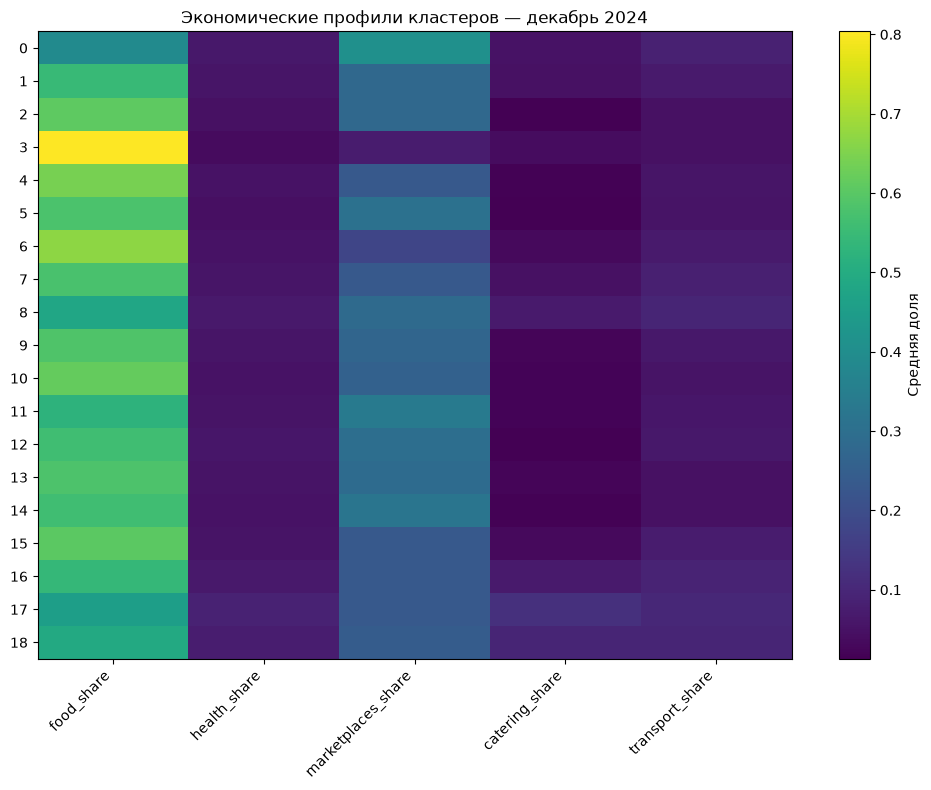

In [8]:
profile_matrix = (
    dec_profiles
    .set_index("cluster")[model_features]
)

plt.figure(figsize=(10, 8))

plt.imshow(
    profile_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(model_features)),
    model_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(profile_matrix)),
    profile_matrix.index
)

plt.colorbar(label="Средняя доля")

plt.title(
    "Экономические профили кластеров — декабрь 2024"
)

plt.tight_layout()
plt.show()

## 7. Описательная статистика профилей

Проверяем диапазоны средних значений по кластерам.

In [9]:
profile_matrix.describe()

,food_share,health_share,marketplaces_share,catering_share,transport_share
count,19.000000,19.000000,19.000000,19.000000,19.000000
mean,0.569495,0.057727,0.263225,0.040573,0.068980
std,0.087331,0.011419,0.068149,0.030105,0.017793
min,0.392363,0.035023,0.074139,0.012858,0.047922
25%,0.531191,0.052064,0.232998,0.018512,0.054426
50%,0.575929,0.055898,0.269339,0.032074,0.064647
75%,0.605856,0.062002,0.294155,0.049537,0.083937
max,0.803722,0.087682,0.408569,0.122226,0.101234


## 8. Внутрикластерная неоднородность

Смотрим стандартные отклонения экономических долей внутри кластерных профилей.

In [10]:
dec_profiles[model_features].std()

food_share            0.087331
health_share          0.011419
marketplaces_share    0.068149
catering_share        0.030105
transport_share       0.017793
dtype: float64

## 9. Сохранение профилей

Сохраняем агрегированные профили для этапа формирования устойчивых экономических типов.

In [11]:
cluster_profiles.to_parquet(
    "../data/processed/cluster_profiles.parquet",
    index=False
)

print("Профили кластеров сохранены.")

Профили кластеров сохранены.
